<a href="https://colab.research.google.com/github/mayurivedpathak01-alt/CodeVedX-Data-Science-Internship/blob/main/Sales_prediction_new_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [12]:
url = "https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv"
df = pd.read_csv(url, index_col=0)

print(df.shape)
df.head()

(200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [13]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


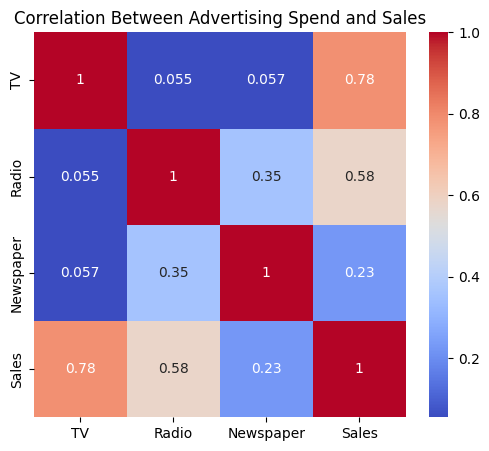

In [4]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Advertising Spend and Sales")
plt.show()

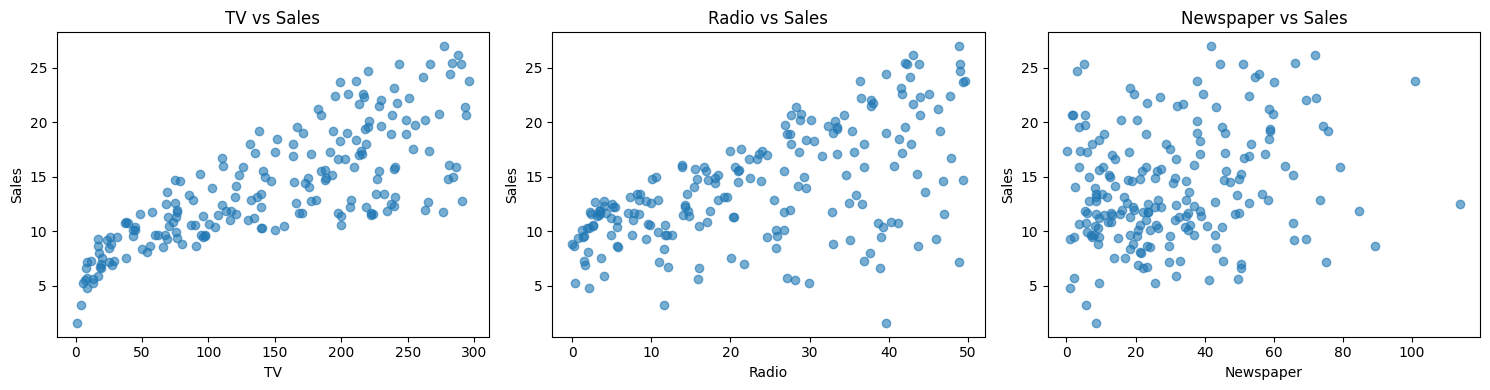

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper']):
    ax.scatter(df[col], df['Sales'], alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel('Sales')
    ax.set_title(f'{col} vs Sales')
plt.tight_layout()
plt.show()

In [14]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Coefficients:", dict(zip(X.columns, model.coef_)))
print("Intercept:", model.intercept_)

Model trained successfully!
Coefficients: {'TV': np.float64(0.044729517468716326), 'Radio': np.float64(0.18919505423437652), 'Newspaper': np.float64(0.0027611143413671935)}
Intercept: 2.979067338122629


In [15]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 3))
print("Mean Squared Error:", round(mse, 3))
print("R² Score:", round(r2, 3))

Mean Absolute Error: 1.461
Mean Squared Error: 3.174
R² Score: 0.899


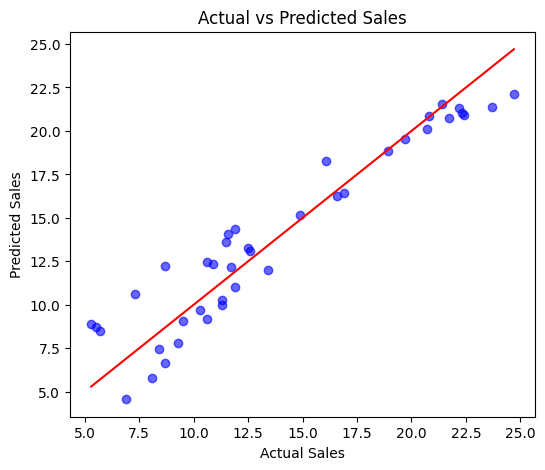

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, color="blue", alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [10]:
new_data = pd.DataFrame({
    "TV": [150],
    "Radio": [25],
    "Newspaper": [30]
})

prediction = model.predict(new_data)
print("Predicted Sales:", round(prediction[0], 2))

Predicted Sales: 14.5


In [ ]:
## Conclusion

The Sales Prediction model was built using Linear Regression on the full Advertising dataset (200 records).
The correlation heatmap and scatter plots show TV and Radio spend have a much stronger relationship with
Sales than Newspaper spend. The model was evaluated using MAE, MSE, and R² Score, and can predict sales
for new advertising budgets.